<a href="https://colab.research.google.com/github/Orca5/AI-ML/blob/master/scanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nselib pandas pytz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [2]:
import pandas as pd
import nselib
print("✅ Pandas Version:", pd.__version__)
print("✅ NSElib is ready to scan.")

✅ Pandas Version: 2.2.2
✅ NSElib is ready to scan.


In [4]:
def run_accumulation_scan(watchlist):
    IST = pytz.timezone('Asia/Kolkata')
    today = datetime.now(IST).strftime('%d-%m-%Y')

    results = []
    for symbol in watchlist:
        try:
            df = capital_market.price_volume_and_deliverable_position_data(symbol, period='1M')

            # --- FIX: Clean column names to remove hidden spaces ---
            df.columns = [col.strip() for col in df.columns]

            # --- FIX: Dynamically find columns even if names vary slightly ---
            # We look for a column that contains 'Dly' or 'Deliverable'
            delivery_col = [c for c in df.columns if 'Dly' in c or 'Delivery' in c][0]
            price_col = [c for c in df.columns if 'Close' in c][0]

            df['Delivery_Pct'] = pd.to_numeric(df[delivery_col], errors='coerce')
            df['Close'] = pd.to_numeric(df[price_col], errors='coerce')

            latest = df.iloc[-1]
            avg_del_10d = df['Delivery_Pct'].tail(10).mean()

            # SIGNAL LOGIC
            price_change = ((latest['Close'] - df['Close'].iloc[-2]) / df['Close'].iloc[-2]) * 100
            is_unusual_delivery = latest['Delivery_Pct'] > (avg_del_10d * 1.2)
            is_high_delivery = latest['Delivery_Pct'] > 50

            status = "⚪ Neutral"
            if is_high_delivery and is_unusual_delivery:
                status = "🟢 STRONG ACCUMULATION"
            elif is_high_delivery:
                status = "🟡 Steady Buying"

            results.append({
                "Symbol": symbol,
                "LTP": latest['Close'],
                "Change %": round(price_change, 2),
                "Delivery %": latest['Delivery_Pct'],
                "10D Avg": round(avg_del_10d, 2),
                "Signal": status
            })
        except Exception as e:
            print(f"Error scanning {symbol}: {e}")

    return pd.DataFrame(results)


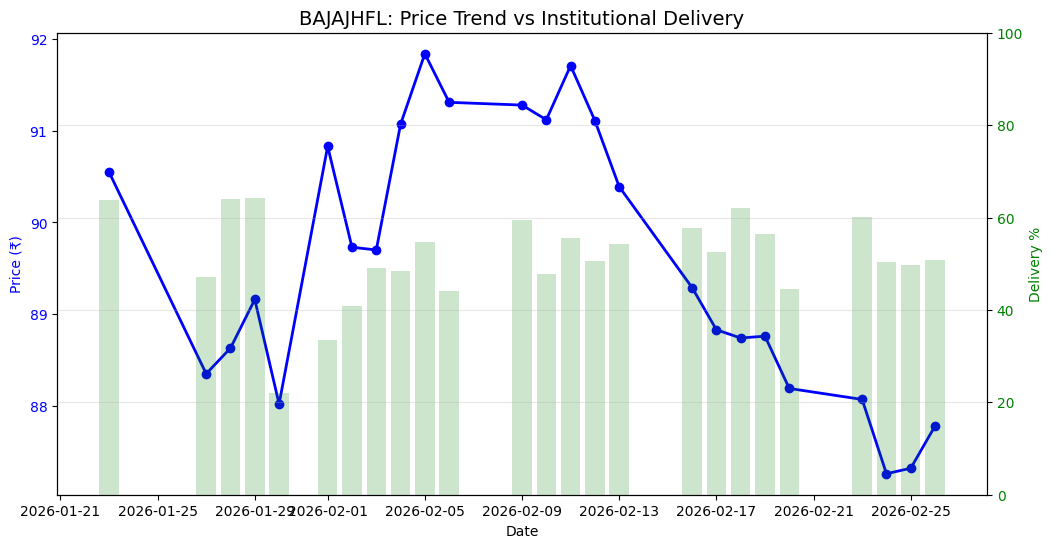

In [6]:
import matplotlib.pyplot as plt

def plot_trend(symbol):
    # Fetch data
    df = capital_market.price_volume_and_deliverable_position_data(symbol, period='1M')

    # --- STEP 1: CLEAN HEADERS (The Fix) ---
    df.columns = [col.strip() for col in df.columns]

    # --- STEP 2: DYNAMICALLY FIND COLUMNS ---
    # This finds the column even if it's 'Close Price' or 'Close' or 'CLOSE'
    date_col = [c for c in df.columns if 'Date' in c][0]
    price_col = [c for c in df.columns if 'Close' in c][0]
    delivery_col = [c for c in df.columns if 'Dly' in c or 'Delivery' in c][0]

    # Ensure Date is in datetime format
    df[date_col] = pd.to_datetime(df[date_col])

    # --- STEP 3: PLOT ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Price (Left Axis)
    ax1.plot(df[date_col], df[price_col], color='blue', marker='o', linewidth=2, label='Price')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price (₹)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Plot Delivery % (Right Axis)
    ax2 = ax1.twinx()
    ax2.bar(df[date_col], df[delivery_col].astype(float), color='green', alpha=0.2, label='Delivery %')
    ax2.set_ylabel('Delivery %', color='green')
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='green')

    plt.title(f"{symbol}: Price Trend vs Institutional Delivery", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the fixed plot
plot_trend('BAJAJHFL')
